In [1]:
import sys

sys.path.append("..")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.models import evaluate_models

df = pd.read_csv("../data/processed/delhi_featured.csv")
leaderboard = evaluate_models(df, target_col="Target_PM25_t1")

print("=== Cross-Validation Benchmark (Log Transform Inverted) ===")
leaderboard

c:\Users\HP\Documents\P_jects\air_quality\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Cross-Validation Benchmark (Log Transform Inverted) ===


,Model,Mean RMSE,Mean MAE,Mean R2
0,Random Forest,42.236,26.456,0.681
1,LightGBM,42.853,27.132,0.670
2,XGBoost,43.480,27.749,0.661
3,CatBoost,44.142,28.401,0.651
4,Baseline (Ridge),52.550,30.352,0.469


<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_6720\239302654.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Model Benchmark: 5-Fold TimeSeriesSplit Mean RMSE ($\mu g/m^3$)")


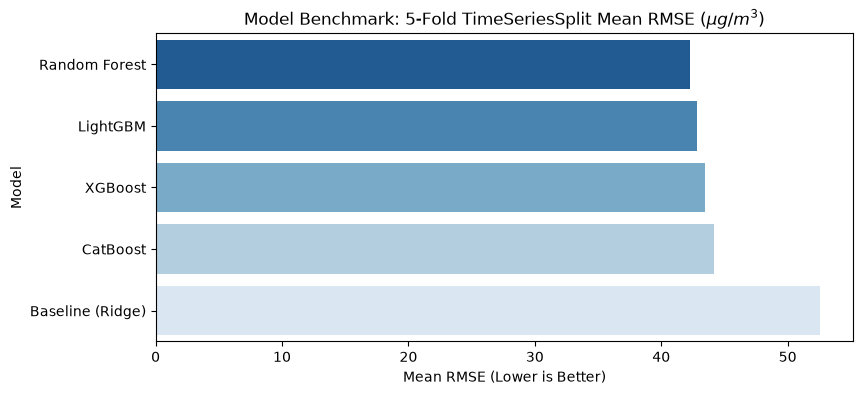

In [2]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=leaderboard,
    x="Mean RMSE",
    y="Model",
    hue="Model",
    legend=False,
    palette="Blues_r",
)
plt.title("Model Benchmark: 5-Fold TimeSeriesSplit Mean RMSE ($\mu g/m^3$)")
plt.xlabel("Mean RMSE (Lower is Better)")
plt.show()

In [3]:
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit

from src.evaluate import plot_predictions
from src.interpret import run_shap_analysis

# Separate features and target
drop_cols = [
    "City",
    "Date",
    "AQI",
    "AQI_Bucket",
    "Target_PM25_t1",
    "Target_NO2_t1",
    "Log_Target_PM25_t1",
    "Log_Target_NO2_t1",
]
feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].values
y = df["Target_PM25_t1"].values

# Outer evaluation fold
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(X):
    pass

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

# Train LightGBM surrogate on log target
model = LGBMRegressor(
    n_estimators=120,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    verbose=-1,
)
model.fit(X_train, np.log1p(y_train))

# Predict and invert
preds = np.expm1(model.predict(X_val))
preds = np.clip(preds, a_min=0, a_max=None)

# Generate plots
plot_predictions(y_val, preds, model_name="LightGBM", output_dir="../figures")
run_shap_analysis(
    model,
    X_train,
    X_val,
    feature_names=feature_cols,
    output_dir="../figures",
)

Saved evaluation plot to: ../figures\lightgbm_eval.png
Saved SHAP summary to: ../figures\shap_summary.png
